# Energy Efficiency Analysis — 최종 통합 

**팀원**: 김근홍, 손수경, 이설현, 이정인, 박연제 · **담당(통합/보고서)**: 박연제

---


## 0. Import & 옵션


In [3]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

import statsmodels.api as sm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스 기호 깨짐 방지

DATA_PATH = "data/ENB2012_data.xlsx"
RANDOM_STATE = 42  # 팀 전체 동일 시드 사용 (재현성)

## 1. 데이터 로드

`eda_stats.py`의 `load_data` 함수를 붙여넣고 실행합니다.

In [6]:
#  eda_stats.py 
#  load_data

FEATURE_COLS = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]
TARGET_COLS = ["Y1", "Y2"]
ALL_COLS = FEATURE_COLS + TARGET_COLS

CATEGORICAL_LIKE_COLS = ["X6", "X8"]

def load_data(path: str) -> pd.DataFrame:

    # 데이터를 로드
    df = pd.read_excel(path)
 
    missing_cols = [c for c in ALL_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"필수 컬럼 누락: {missing_cols}")
    df = df[ALL_COLS]  # 컬럼 순서 고정

    n_missing = df.isnull().sum().sum()
    if n_missing > 0:
        print(f"결측치: {n_missing}개")

    print(f"데이터 로드 완료: {df.shape[0]}행 x {df.shape[1]}열")
    return df

    raise NotImplementedError



In [7]:
df = load_data(DATA_PATH)
df.head()

데이터 로드 완료: 768행 x 10열


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## 2. 기술통계 (`eda_stats.py`)

중심화(평균·중앙값·최빈값), 퍼짐(표준편차·CV·사분위수·IQR), 분포/대칭(왜도·첨도)을 확인합니다.

In [8]:
# eda_stats.py 
# central_tendency, dispersion, shape_stats, build_summary_table 
# 중심화 통계량: 평균, 중앙값, 최빈값
def central_tendency(df: pd.DataFrame) -> pd.DataFrame:
    result = pd.DataFrame({
        "mean": df.mean(),
        "median": df.median(),
        "mode": df.mode().iloc[0],  # 최빈값이 여러 개면 그중 첫 번째
    })
    result.index.name = "variable"
    return result
 
# 퍼짐 통계량: 표준편차, 변이계수(CV), 1사분위수(Q1), 3사분위수(Q3), IQR
def dispersion(df: pd.DataFrame) -> pd.DataFrame:
 
    std = df.std()
    mean = df.mean()
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3 - q1
    cv = std / mean
 
    result = pd.DataFrame({
        "std": std,
        "cv": cv,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
    })
    result.index.name = "variable"
    return result
 
# 분포/대칭 통계량: 왜도, 첨도
def shape_stats(df: pd.DataFrame) -> pd.DataFrame:

    result = pd.DataFrame({
        "skew": df.skew(), # 왜도 
        "kurtosis": df.kurt(), # 첨도 
    })
    result.index.name = "variable"
    result["is_categorical_like"] = result.index.isin(CATEGORICAL_LIKE_COLS)
    return result
 
# central_tendency, dispersion, shape_stats 결과를 하나의 표로 합쳐 eda_summary.csv로 저장
def build_summary_table(df: pd.DataFrame, save_path: str = "report/eda_summary.csv") -> pd.DataFrame:
    
    ct = central_tendency(df)
    disp = dispersion(df)
    shape = shape_stats(df)
 
    summary = pd.concat([ct, disp, shape], axis=1)
    summary = summary.round(4)
 
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    summary.to_csv(save_path)
 
    return summary
 
 
if __name__ == "__main__":
    # 모듈 단독 실행 시 동작 확인용
    df = load_data("data/ENB2012_data.xlsx")
    summary = build_summary_table(df)
    print(summary)
 

데이터 로드 완료: 768행 x 10열
              mean  median    mode      std      cv        q1        q3       iqr    skew  kurtosis  \
variable                                                                                              
X1          0.7642    0.75    0.62   0.1058  0.1384    0.6825    0.8300    0.1475  0.4955   -0.7066   
X2        671.7083  673.75  514.50  88.0861  0.1311  606.3750  741.1250  134.7500 -0.1251   -1.0595   
X3        318.5000  318.50  294.00  43.6265  0.1370  294.0000  343.0000   49.0000  0.5334    0.1166   
X4        176.6042  183.75  220.50  45.1660  0.2557  140.8750  220.5000   79.6250 -0.1628   -1.7769   
X5          5.2500    5.25    3.50   1.7511  0.3336    3.5000    7.0000    3.5000  0.0000   -2.0052   
X6          3.5000    3.50    2.00   1.1188  0.3196    2.7500    4.2500    1.5000  0.0000   -1.3610   
X7          0.2344    0.25    0.10   0.1332  0.5684    0.1000    0.4000    0.3000 -0.0603   -1.3276   
X8          2.8125    3.00    1.00   1.5510  0.5515

In [9]:
ct = central_tendency(df) # 중심화 통계량: 평균, 중앙값, 최빈값
ct

,mean,median,mode
variable,,,
X1,0.764167,0.75,0.62
X2,671.708333,673.75,514.50
X3,318.500000,318.50,294.00
X4,176.604167,183.75,220.50
X5,5.250000,5.25,3.50
X6,3.500000,3.50,2.00
X7,0.234375,0.25,0.10
X8,2.812500,3.00,1.00
Y1,22.307195,18.95,15.16


In [10]:
disp = dispersion(df) # 퍼짐 통계량: 표준편차, 변이계수(CV), 1사분위수(Q1), 3사분위수(Q3), IQR
disp

,std,cv,q1,q3,iqr
variable,,,,,
X1,0.105777,0.138422,0.6825,0.8300,0.1475
X2,88.086116,0.131137,606.3750,741.1250,134.7500
X3,43.626481,0.136975,294.0000,343.0000,49.0000
X4,45.165950,0.255747,140.8750,220.5000,79.6250
X5,1.751140,0.333551,3.5000,7.0000,3.5000
X6,1.118763,0.319646,2.7500,4.2500,1.5000
X7,0.133221,0.568408,0.1000,0.4000,0.3000
X8,1.550960,0.551452,1.7500,4.0000,2.2500
Y1,10.090204,0.452330,12.9925,31.6675,18.6750


In [11]:
shape = shape_stats(df) # 분포/대칭 통계량: 왜도, 첨도
shape

,skew,kurtosis,is_categorical_like
variable,,,
X1,0.495513,-0.706568,False
X2,-0.125131,-1.059454,False
X3,0.533417,0.116593,False
X4,-0.162764,-1.776947,False
X5,0.000000,-2.005229,False
X6,0.000000,-1.361042,True
X7,-0.060254,-1.327629,False
X8,-0.088689,-1.148709,True
Y1,0.360446,-1.245569,False


In [12]:
summary = build_summary_table(df) # central_tendency, dispersion, shape_stats 결과를 하나의 표로 합쳐 eda_summary.csv로 저장
summary

,mean,median,mode,std,cv,q1,q3,iqr,skew,kurtosis,is_categorical_like
variable,,,,,,,,,,,
X1,0.7642,0.75,0.62,0.1058,0.1384,0.6825,0.8300,0.1475,0.4955,-0.7066,False
X2,671.7083,673.75,514.50,88.0861,0.1311,606.3750,741.1250,134.7500,-0.1251,-1.0595,False
X3,318.5000,318.50,294.00,43.6265,0.1370,294.0000,343.0000,49.0000,0.5334,0.1166,False
X4,176.6042,183.75,220.50,45.1660,0.2557,140.8750,220.5000,79.6250,-0.1628,-1.7769,False
X5,5.2500,5.25,3.50,1.7511,0.3336,3.5000,7.0000,3.5000,0.0000,-2.0052,False
X6,3.5000,3.50,2.00,1.1188,0.3196,2.7500,4.2500,1.5000,0.0000,-1.3610,True
X7,0.2344,0.25,0.10,0.1332,0.5684,0.1000,0.4000,0.3000,-0.0603,-1.3276,False
X8,2.8125,3.00,1.00,1.5510,0.5515,1.7500,4.0000,2.2500,-0.0887,-1.1487,True
Y1,22.3072,18.95,15.16,10.0902,0.4523,12.9925,31.6675,18.6750,0.3604,-1.2456,False


## 3. 시각화 (`visualization.py`)

변수별 분포와 X-Y 산점도를 확인합니다.

데이터 불러오기 완료: /Users/yeonjep/Desktop/SKALA/SKALA_4/Data anaylizing_statistic/energy-efficiency-analysis/data/ENB2012_data.xlsx (768행 x 10열)


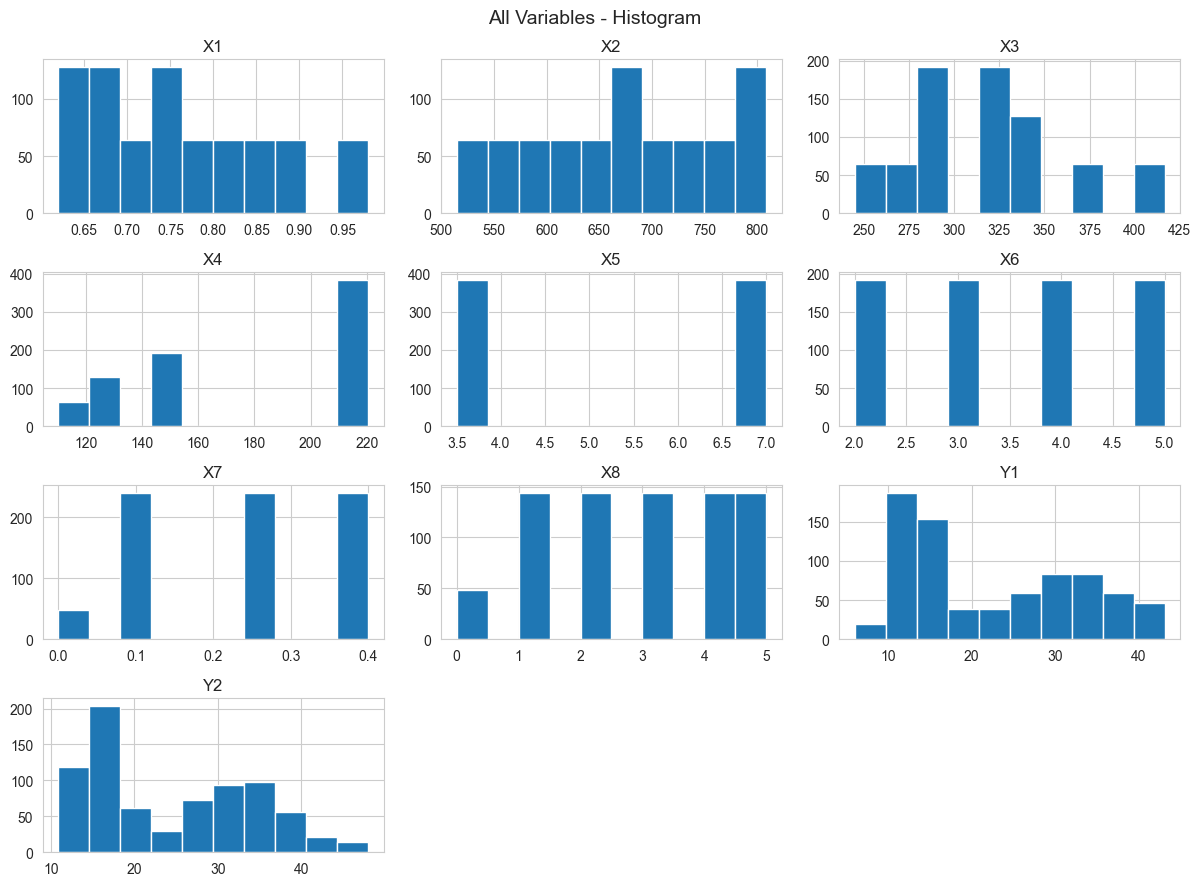

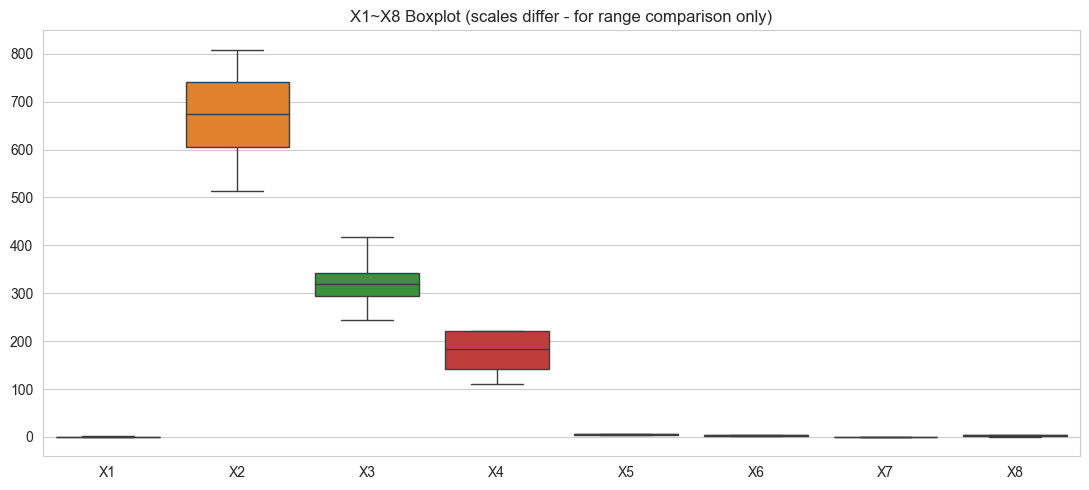

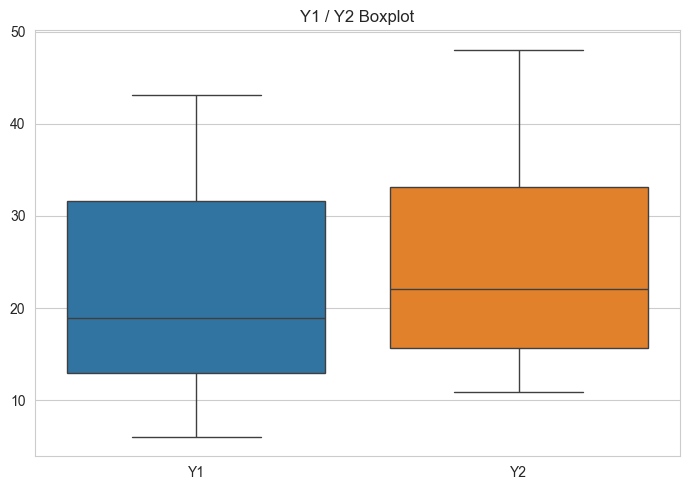

[분포] X1 (Relative Compactness)
    평균 0.76 / 중앙값 0.75 / 표준편차 0.11
    Q1 0.68 / Q3 0.83 / IQR 0.15 / 이상치 후보 0개
    왜도 0.50 / 첨도 -0.71


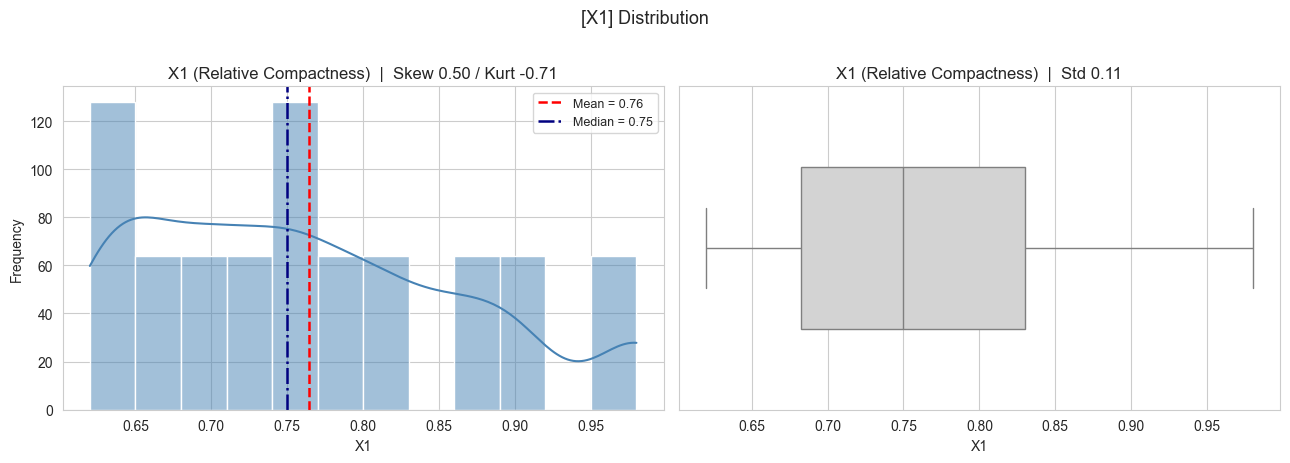

[분포] X2 (Surface Area)
    평균 671.71 / 중앙값 673.75 / 표준편차 88.09
    Q1 606.38 / Q3 741.12 / IQR 134.75 / 이상치 후보 0개
    왜도 -0.13 / 첨도 -1.06


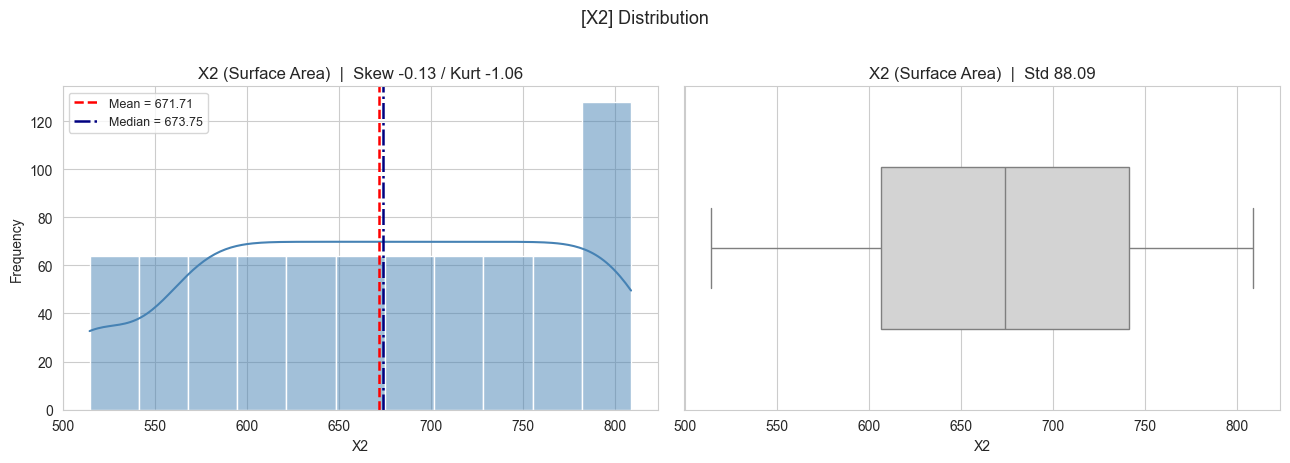

[분포] X3 (Wall Area)
    평균 318.50 / 중앙값 318.50 / 표준편차 43.63
    Q1 294.00 / Q3 343.00 / IQR 49.00 / 이상치 후보 0개
    왜도 0.53 / 첨도 0.12


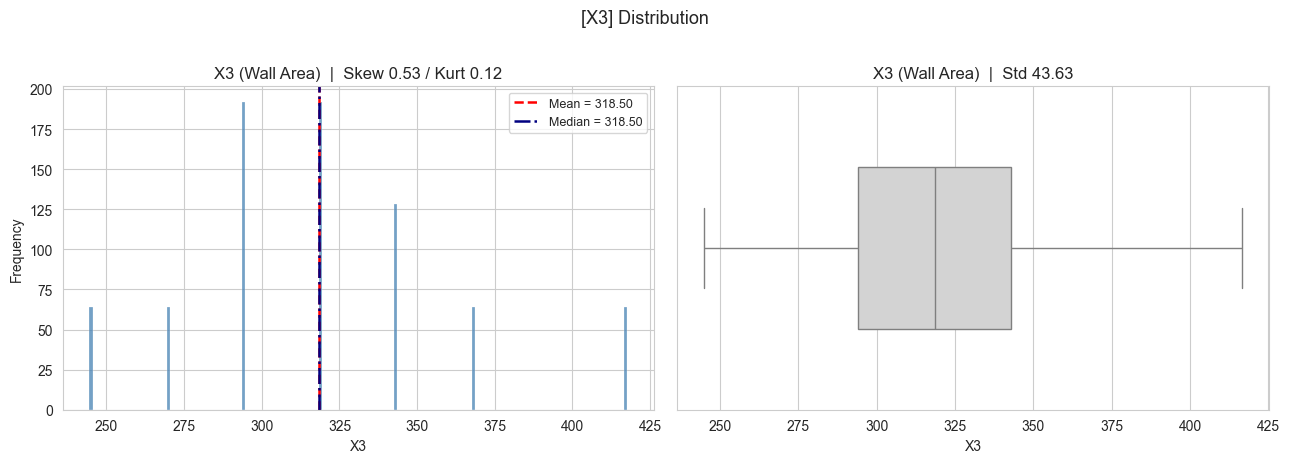

[분포] X4 (Roof Area)
    평균 176.60 / 중앙값 183.75 / 표준편차 45.17
    Q1 140.88 / Q3 220.50 / IQR 79.62 / 이상치 후보 0개
    왜도 -0.16 / 첨도 -1.78


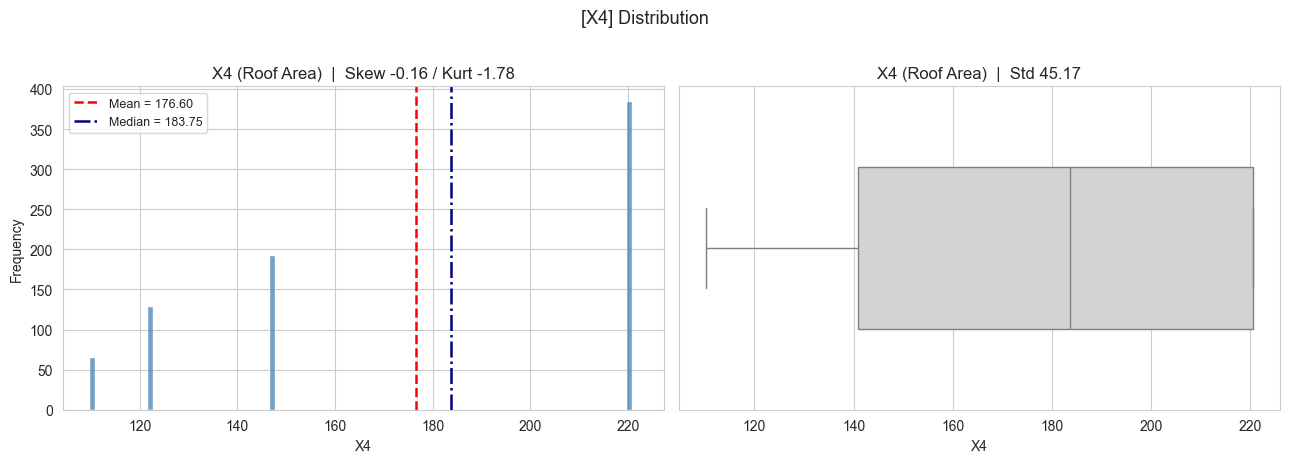

[분포] X5 (Overall Height)
    평균 5.25 / 중앙값 5.25 / 표준편차 1.75
    Q1 3.50 / Q3 7.00 / IQR 3.50 / 이상치 후보 0개
    왜도 0.00 / 첨도 -2.01


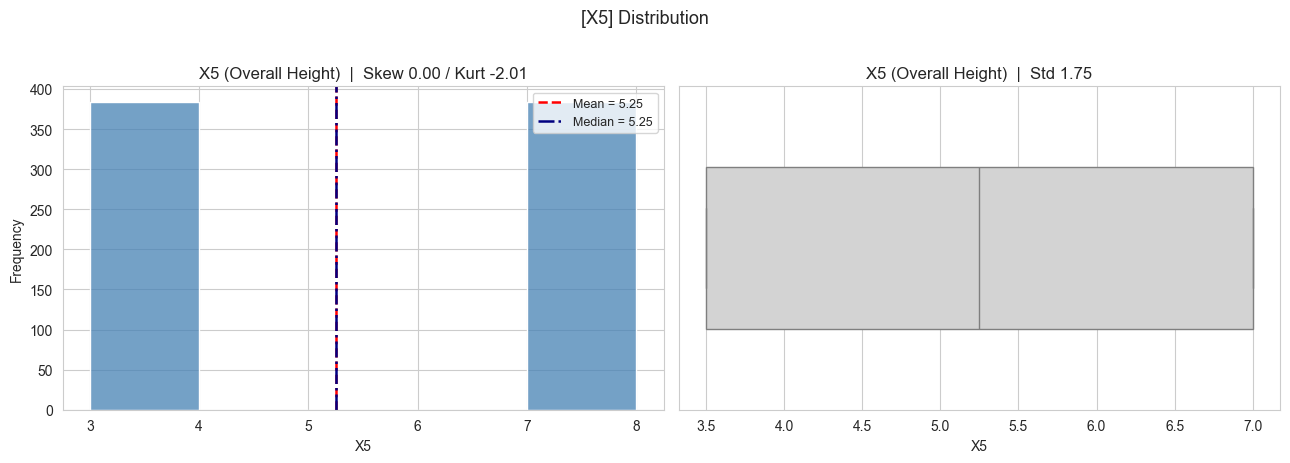

[분포] X6 (Orientation)
    평균 3.50 / 중앙값 3.50 / 표준편차 1.12
    Q1 2.75 / Q3 4.25 / IQR 1.50 / 이상치 후보 0개
    왜도 0.00 / 첨도 -1.36


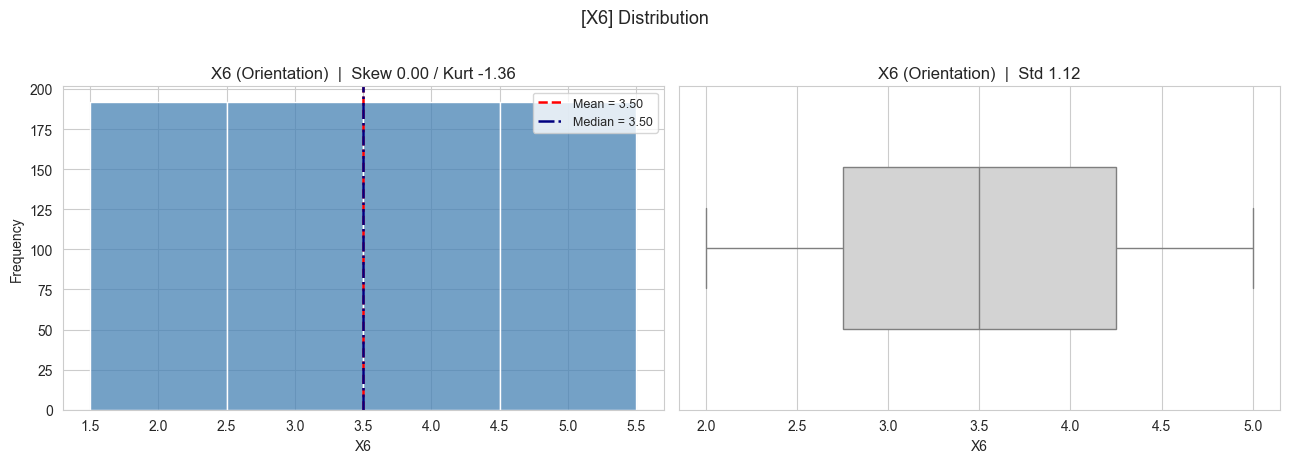

[분포] X7 (Glazing Area)
    평균 0.23 / 중앙값 0.25 / 표준편차 0.13
    Q1 0.10 / Q3 0.40 / IQR 0.30 / 이상치 후보 0개
    왜도 -0.06 / 첨도 -1.33


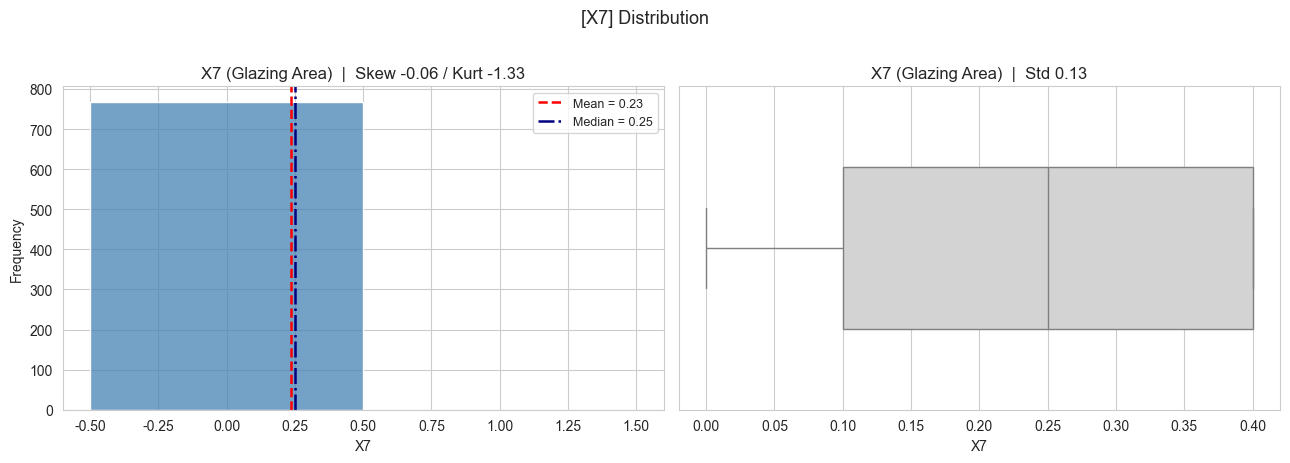

[분포] X8 (Glazing Area Distribution)
    평균 2.81 / 중앙값 3.00 / 표준편차 1.55
    Q1 1.75 / Q3 4.00 / IQR 2.25 / 이상치 후보 0개
    왜도 -0.09 / 첨도 -1.15


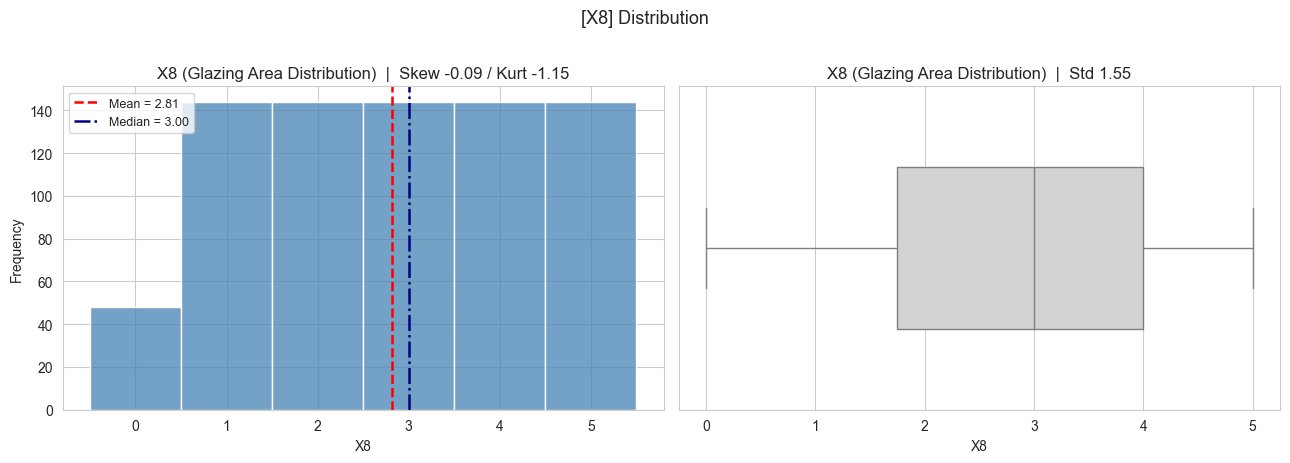

[분포] Y1 (Heating Load)
    평균 22.31 / 중앙값 18.95 / 표준편차 10.09
    Q1 12.99 / Q3 31.67 / IQR 18.68 / 이상치 후보 0개
    왜도 0.36 / 첨도 -1.25


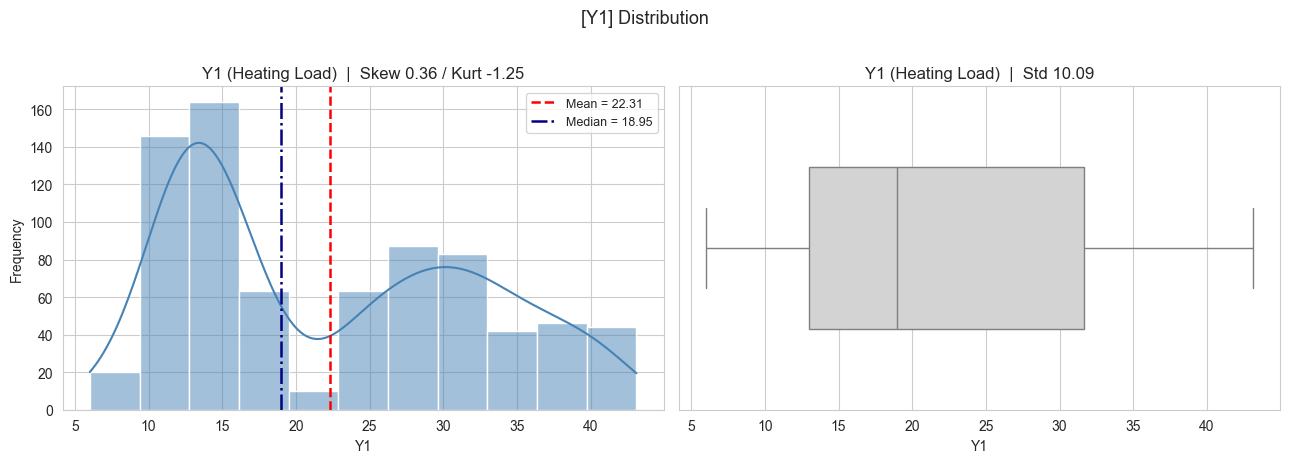

[분포] Y2 (Cooling Load)
    평균 24.59 / 중앙값 22.08 / 표준편차 9.51
    Q1 15.62 / Q3 33.13 / IQR 17.51 / 이상치 후보 0개
    왜도 0.40 / 첨도 -1.15


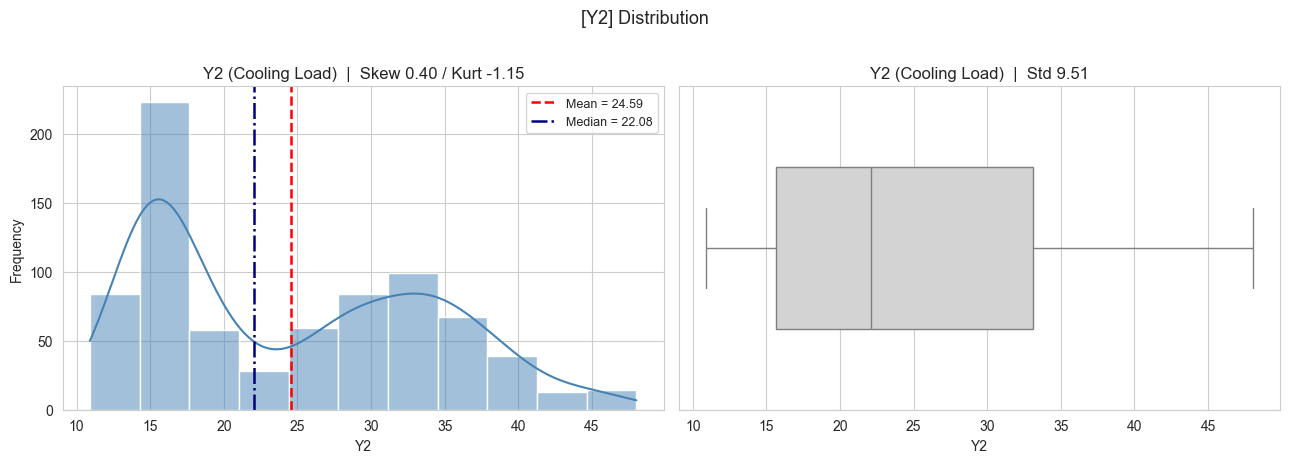

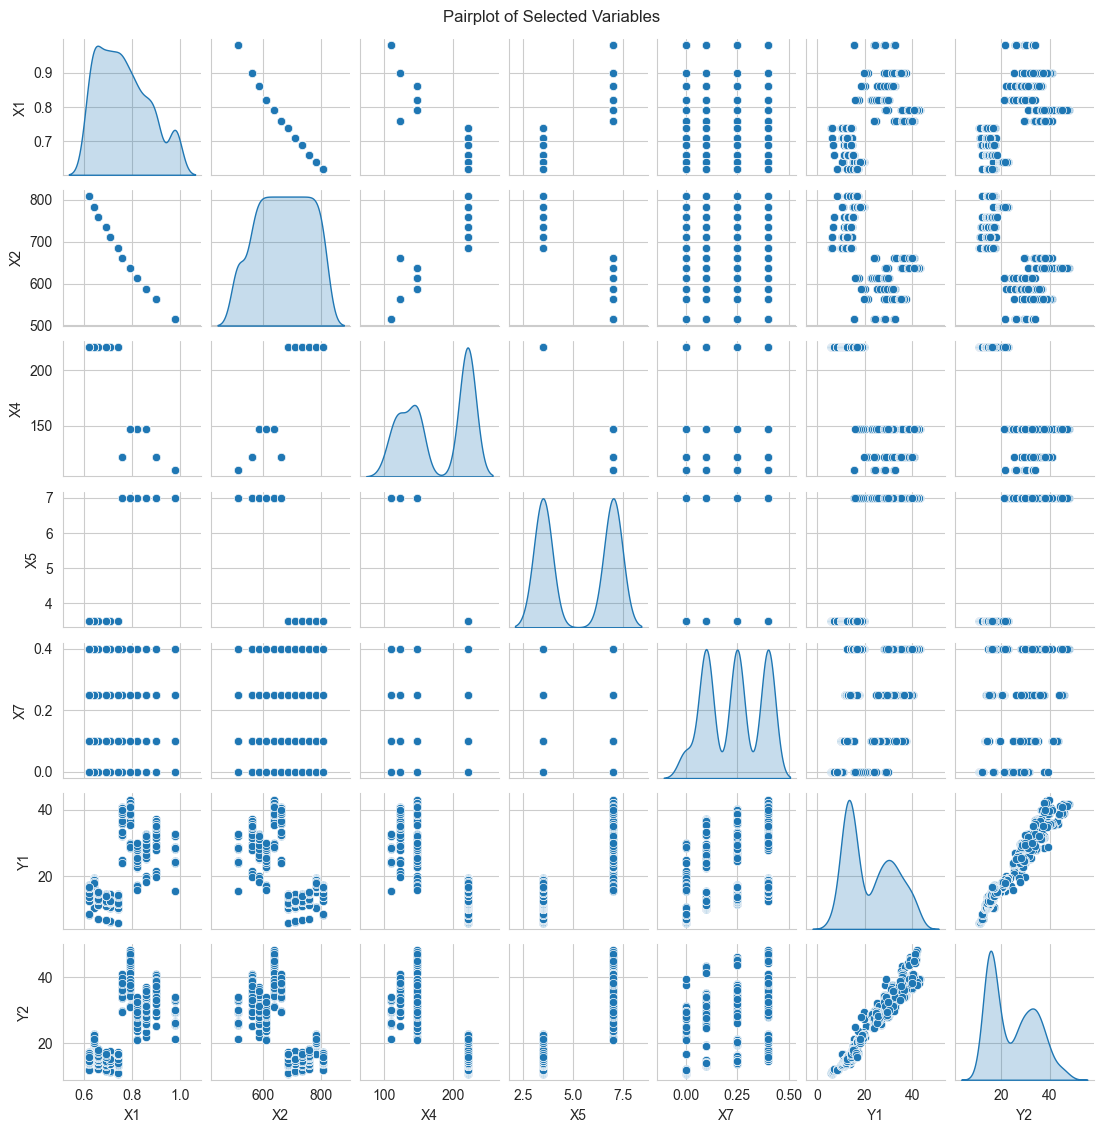

[산점도] X1 - Y1 : 상관계수 r = 0.622


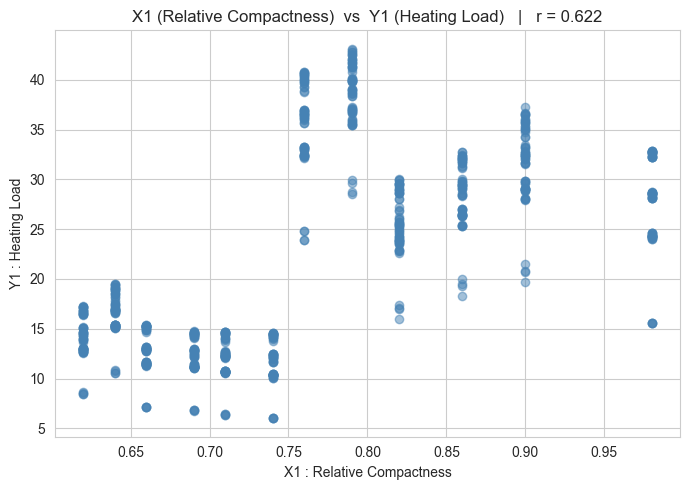

[산점도] X1 - Y2 : 상관계수 r = 0.634


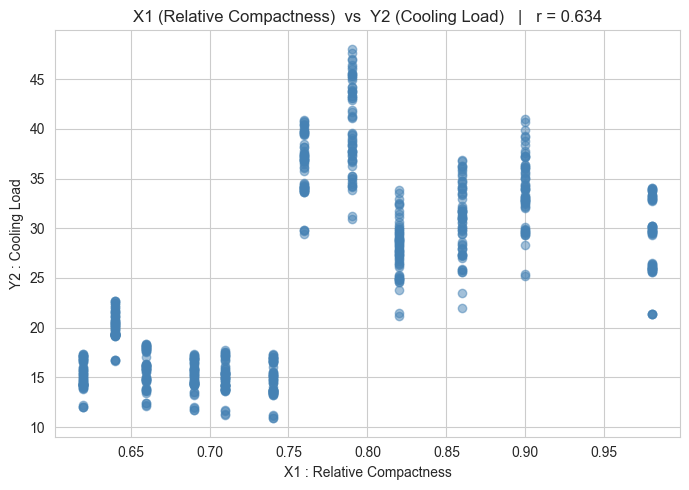

[산점도] X2 - Y1 : 상관계수 r = -0.658


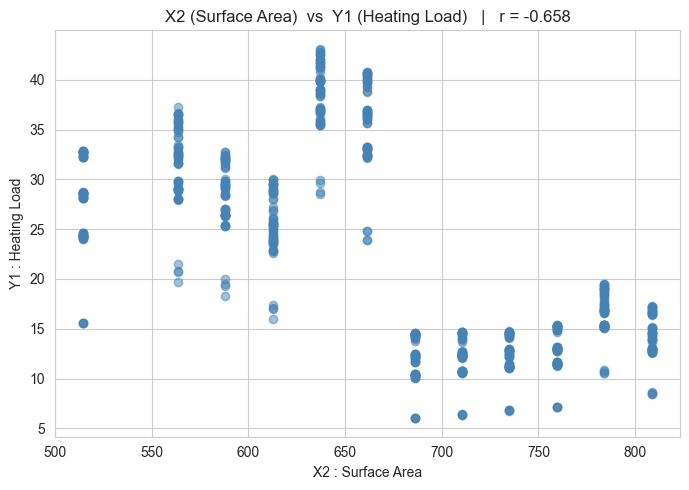

[산점도] X2 - Y2 : 상관계수 r = -0.673


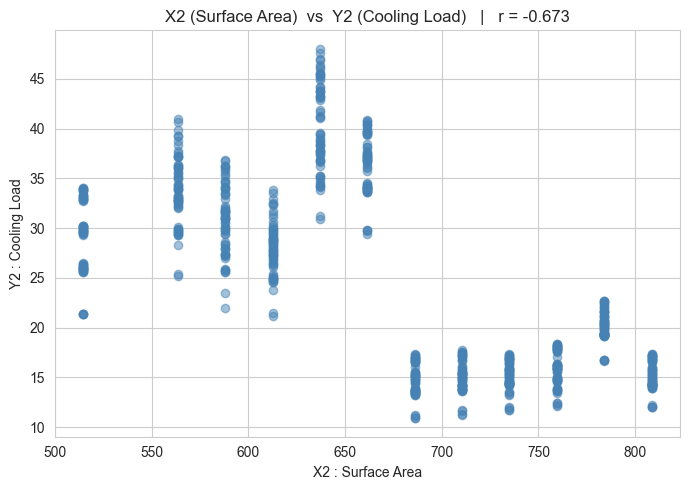

[산점도] X3 - Y1 : 상관계수 r = 0.456


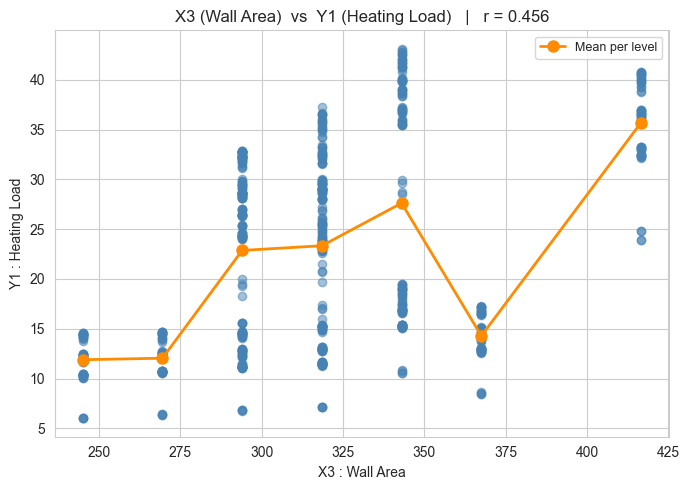

[산점도] X3 - Y2 : 상관계수 r = 0.427


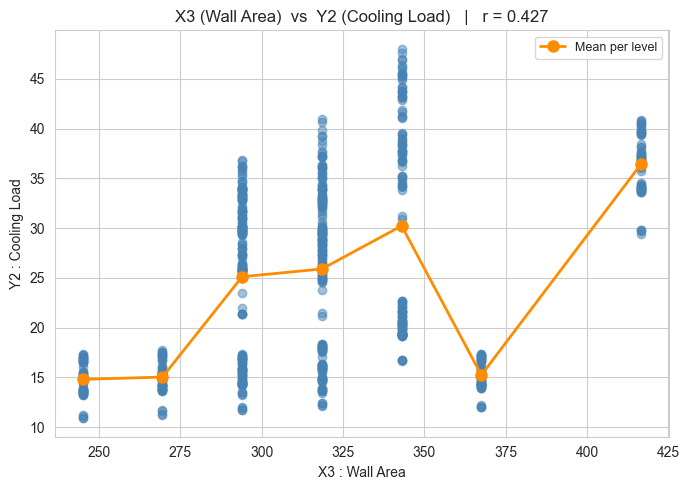

[산점도] X4 - Y1 : 상관계수 r = -0.862


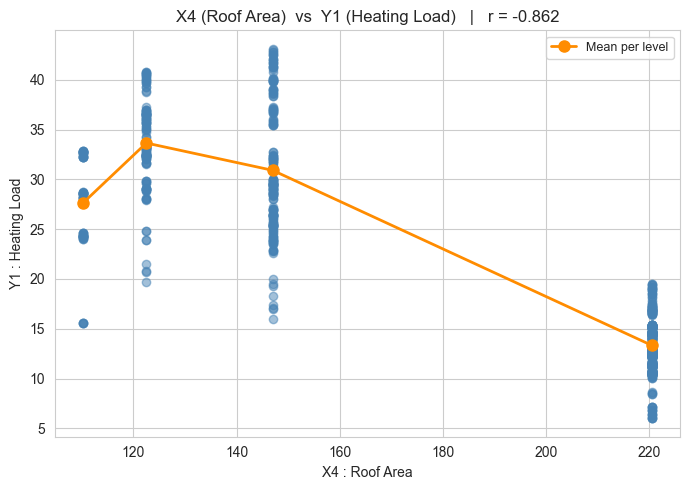

[산점도] X4 - Y2 : 상관계수 r = -0.863


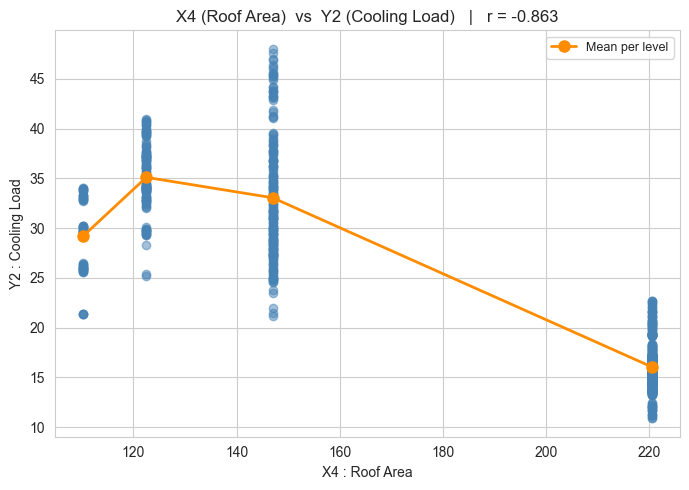

[산점도] X5 - Y1 : 상관계수 r = 0.889


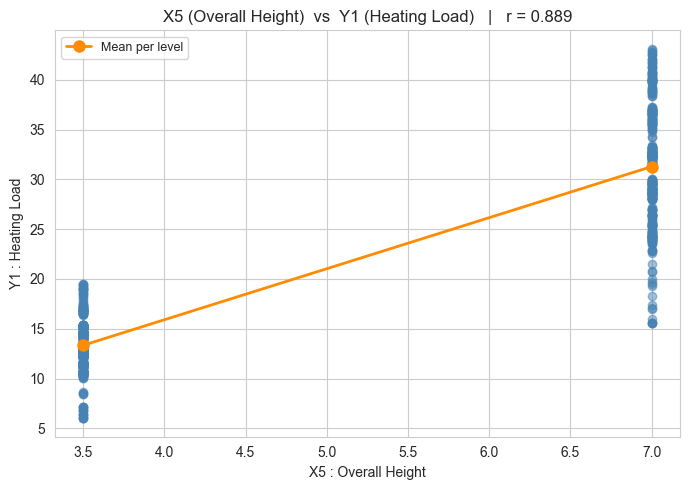

[산점도] X5 - Y2 : 상관계수 r = 0.896


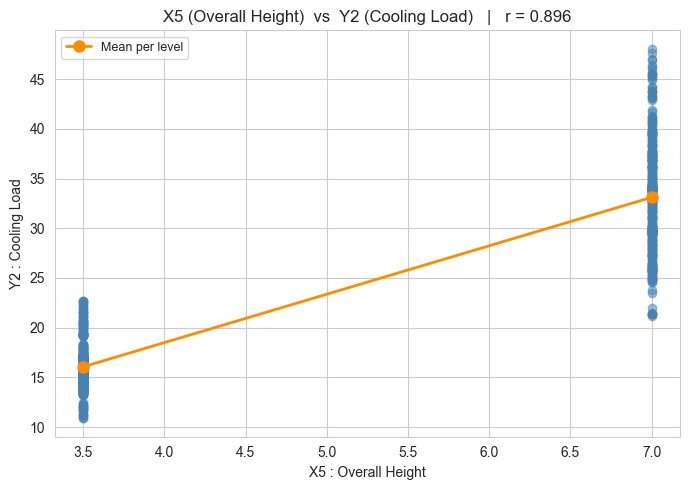

[산점도] X6 - Y1 : 상관계수 r = -0.003


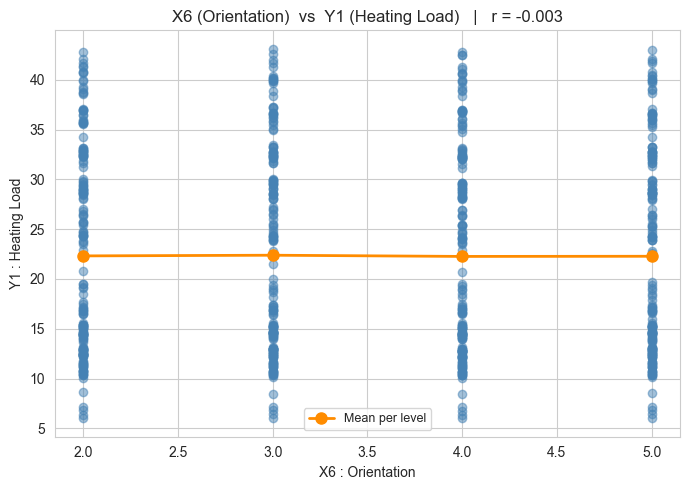

[산점도] X6 - Y2 : 상관계수 r = 0.014


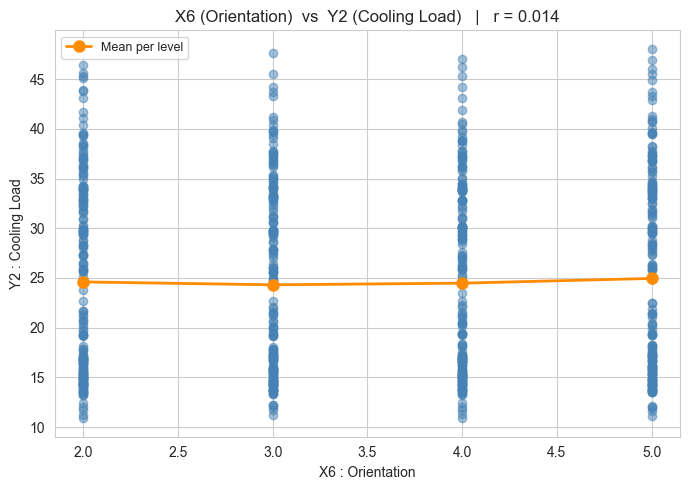

[산점도] X7 - Y1 : 상관계수 r = 0.270


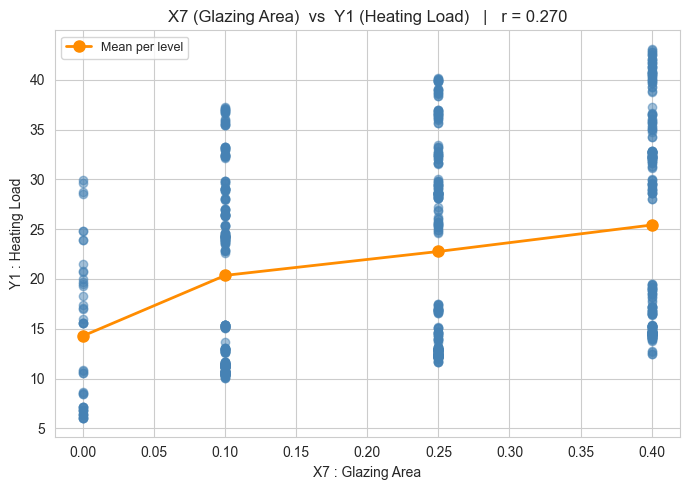

[산점도] X7 - Y2 : 상관계수 r = 0.208


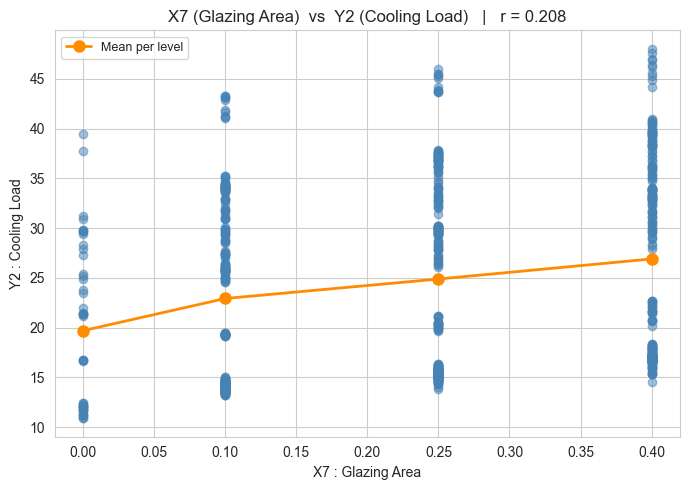

[산점도] X8 - Y1 : 상관계수 r = 0.087


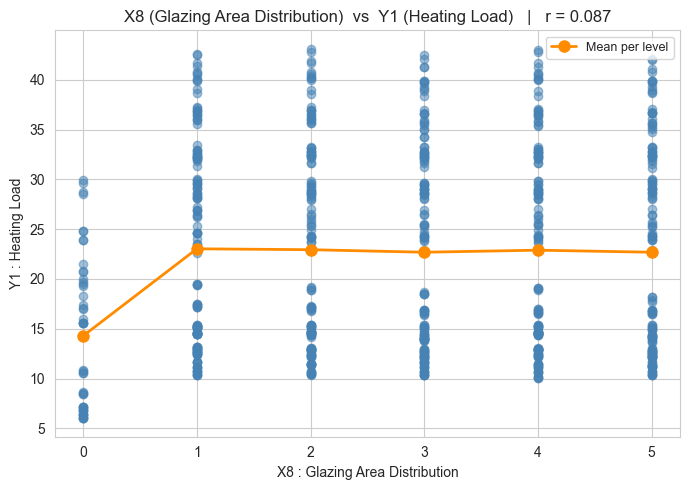

[산점도] X8 - Y2 : 상관계수 r = 0.051


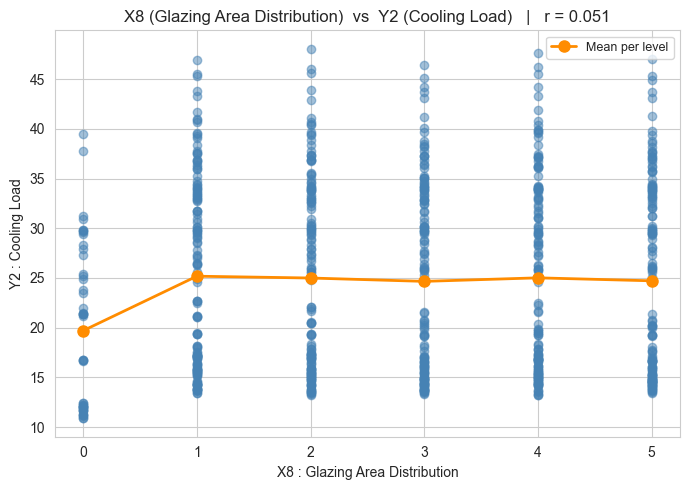

[수준별 평균] X3 (Wall Area)
          Y1     Y2
X3                 
245.0  11.89  14.81
269.5  12.04  15.04
294.0  22.86  25.12
318.5  23.33  25.91
343.0  27.61  30.23
367.5  14.28  15.24
416.5  35.66  36.41


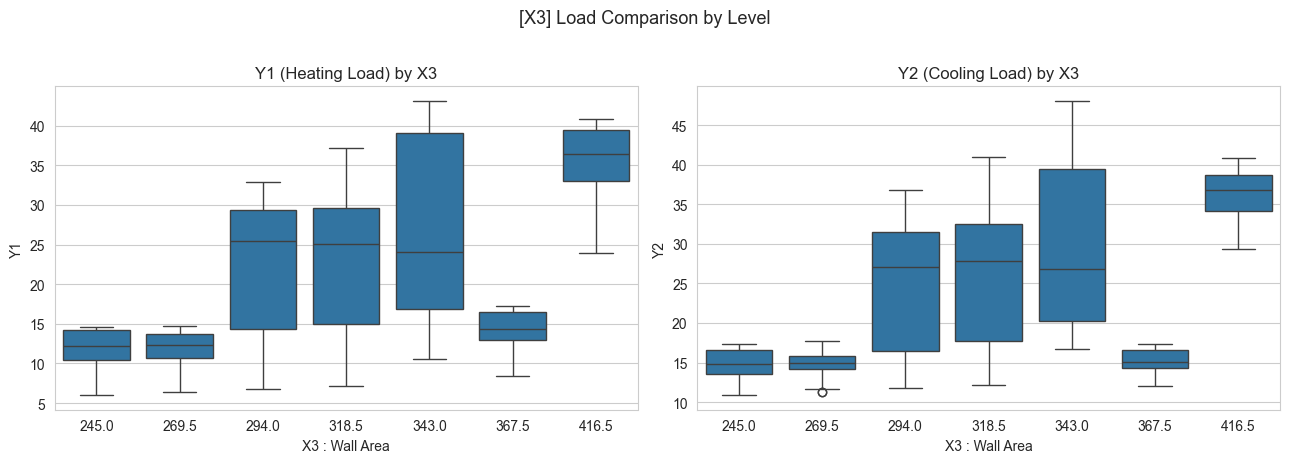

[수준별 평균] X4 (Roof Area)
           Y1     Y2
X4                  
110.25  27.65  29.22
122.50  33.65  35.11
147.00  30.91  33.06
220.50  13.34  16.07


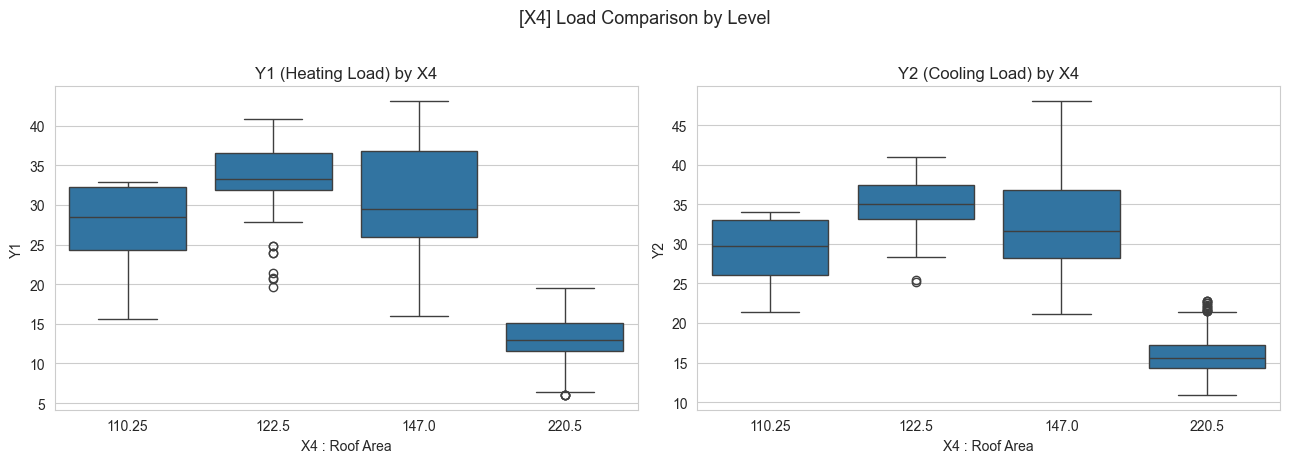

[수준별 평균] X5 (Overall Height)
        Y1     Y2
X5               
3.5  13.34  16.07
7.0  31.28  33.10


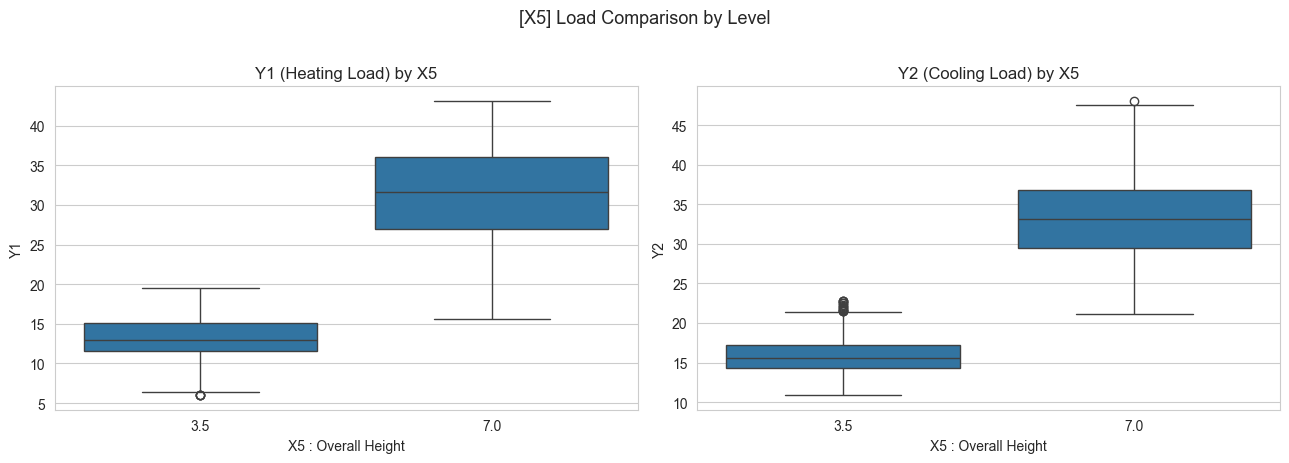

[수준별 평균] X6 (Orientation)
       Y1     Y2
X6              
2   22.31  24.60
3   22.38  24.31
4   22.26  24.48
5   22.28  24.95


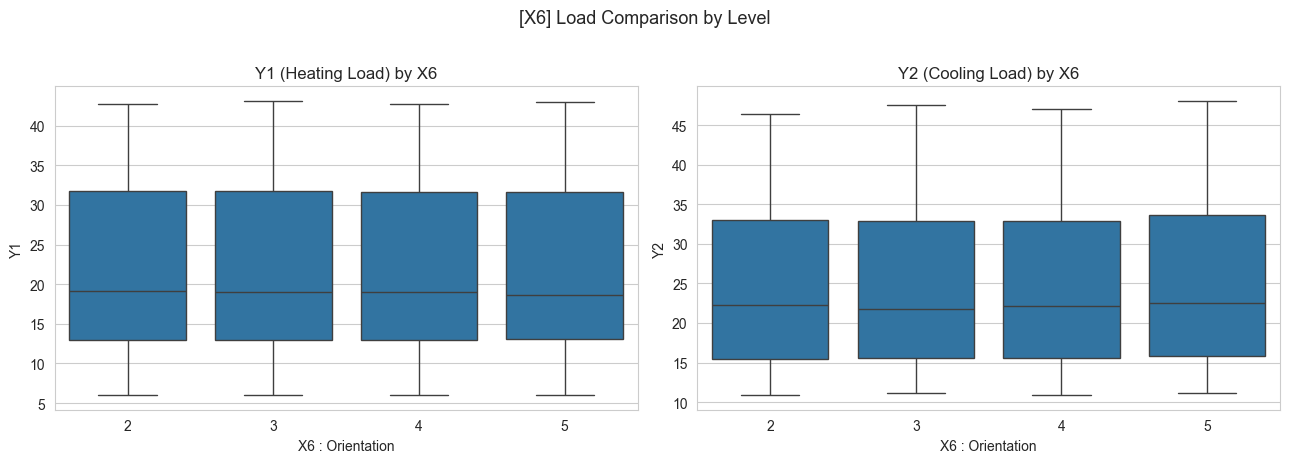

[수준별 평균] X7 (Glazing Area)
         Y1     Y2
X7                
0.00  14.29  19.71
0.10  20.36  22.94
0.25  22.76  24.89
0.40  25.41  26.91


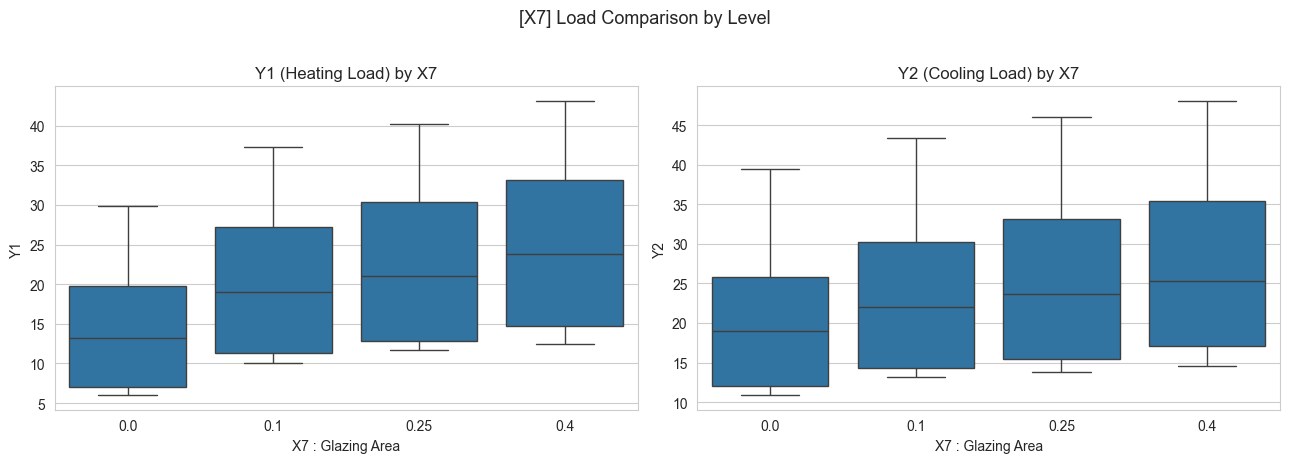

[수준별 평균] X8 (Glazing Area Distribution)
       Y1     Y2
X8              
0   14.29  19.71
1   23.03  25.18
2   22.93  25.00
3   22.68  24.66
4   22.89  25.02
5   22.68  24.72


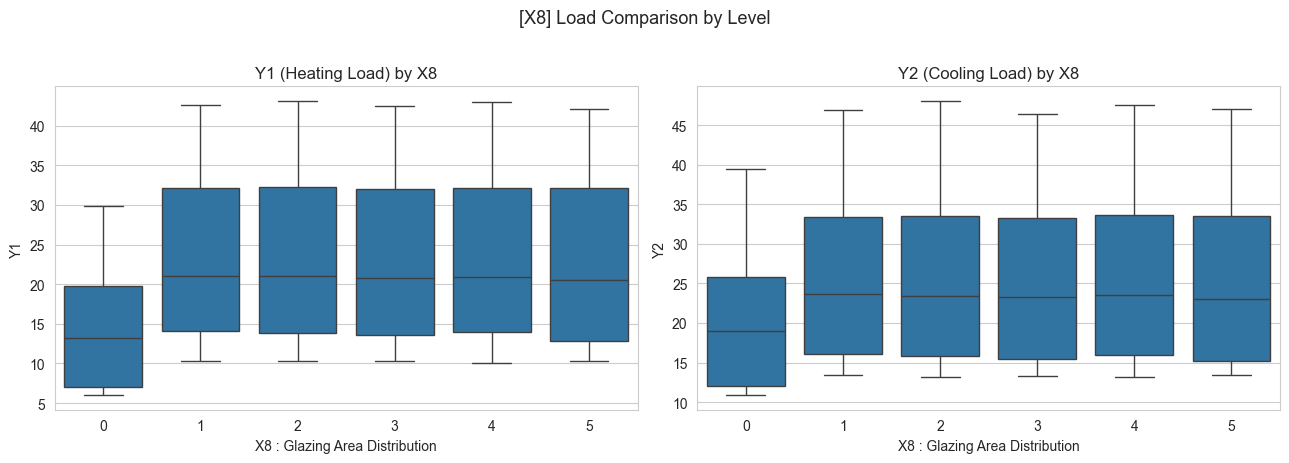


[ 기초통계량 요약 ]
         평균     중앙값    표준편차   변이계수     왜도     첨도
X1    0.764    0.75   0.106  0.138  0.496 -0.707
X2  671.708  673.75  88.086  0.131 -0.125 -1.059
X3  318.500  318.50  43.626  0.137  0.533  0.117
X4  176.604  183.75  45.166  0.256 -0.163 -1.777
X5    5.250    5.25   1.751  0.334  0.000 -2.005
X6    3.500    3.50   1.119  0.320  0.000 -1.361
X7    0.234    0.25   0.133  0.568 -0.060 -1.328
X8    2.812    3.00   1.551  0.551 -0.089 -1.149
Y1   22.307   18.95  10.090  0.452  0.360 -1.246
Y2   24.588   22.08   9.513  0.387  0.396 -1.147

[ X 변수와 목표변수의 상관계수 ]
       Y1     Y2
X1  0.622  0.634
X2 -0.658 -0.673
X3  0.456  0.427
X4 -0.862 -0.863
X5  0.889  0.896
X6 -0.003  0.014
X7  0.270  0.208
X8  0.087  0.051

Y1과 상관계수 절댓값이 가장 큰 변수: X5, 가장 작은 변수: X6

모든 시각화가 완료되었습니다.


In [ ]:
"""
visualization.py -- 0728 실습과제 / ② 시각화 담당 모듈

[ 제공 함수 (조별 공유 시그니처) ]
    load_data(path)              : 데이터 로드 (①번 eda_stats.py 와 시그니처 동일)
    plot_distribution(df, col)   : 변수 1개 히스토그램 + 박스플롯
    plot_all_distributions(df)   : X1~X8, Y1, Y2 일괄 출력
    plot_scatter(df, x, y)       : X-Y 산점도 1개
    plot_all_x_vs_y(df)          : X-Y 산점도 일괄 출력 (16개)

[ 추가 함수 (해석용) ]
    plot_overview(df), plot_pairplot(df), plot_group_mean(df, col),
    plot_all_group_means(df), print_visualization_insights(df), run_all(df)
"""


# =============================================================================
# 0. 기본 설정 (함수들이 참조하는 전역 상수 -- 반드시 함수보다 먼저 있어야 함)
# =============================================================================

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["axes.unicode_minus"] = False  # 음수 기호(-) 깨짐 방지

# 열 이름은 X1~X8, Y1, Y2 그대로 유지(조원 간 통일), 의미는 그래프 제목에만 표시
VARIABLE_LABELS = {
    "X1": "Relative Compactness",
    "X2": "Surface Area",
    "X3": "Wall Area",
    "X4": "Roof Area",
    "X5": "Overall Height",
    "X6": "Orientation",
    "X7": "Glazing Area",
    "X8": "Glazing Area Distribution",
    "Y1": "Heating Load",
    "Y2": "Cooling Load",
}

X_COLUMNS = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]
Y_COLUMNS = ["Y1", "Y2"]
ALL_COLUMNS = X_COLUMNS + Y_COLUMNS

DISCRETE_MAX_UNIQUE = 10  # 값 종류가 이 이하면 이산형으로 취급

try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()  # 노트북 셀에 직접 붙여넣은 경우

COLOR_MAIN = "steelblue"
COLOR_MEAN = "red"
COLOR_MEDIAN = "navy"
COLOR_LEVEL = "darkorange"

SAVE_FIGURES = True  # True로 바꾸면 visualization_results/ 에 png 저장
OUTPUT_DIR = os.path.join(BASE_DIR, "visualization_results")


def save_figure(fig, filename):
    """SAVE_FIGURES가 True일 때만 png로 저장 (False면 그냥 반환)."""
    if not SAVE_FIGURES:
        return
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"    (이미지 저장 완료: {save_path})")


# =============================================================================
# 1. 데이터 로드
# =============================================================================

def _find_data_file(path):
    """조원별 폴더 구조 차이에 대응해 데이터 파일 위치를 자동 탐색 (내부용)."""
    if os.path.exists(path):
        return os.path.abspath(path)

    filename = os.path.basename(path)
    candidate_paths = [
        # 프로젝트 구조상 실제 위치: <프로젝트 루트>/data/ENB2012_data.xlsx
        os.path.join(BASE_DIR, "data", filename),
        os.path.join(os.getcwd(), "data", filename),
        os.path.join(BASE_DIR, "..", "data", filename),
        os.path.join(os.getcwd(), "..", "data", filename),
        # 예전 방식(코드-데이터 동일 폴더, 코드 하위 폴더 구조)도 계속 지원
        os.path.join(BASE_DIR, "..", filename),
        os.path.join(BASE_DIR, filename),
        os.path.join(os.getcwd(), "..", filename),
        os.path.join(os.getcwd(), filename),
    ]

    checked = []
    for candidate in candidate_paths:
        full_path = os.path.abspath(candidate)
        if full_path in checked:
            continue
        checked.append(full_path)
        if os.path.exists(full_path):
            return full_path

    checked_text = "\n".join(f"    - {p}" for p in checked)
    raise FileNotFoundError(
        f"'{filename}' 파일을 찾을 수 없습니다.\n"
        f"확인한 경로:\n{checked_text}\n\n"
        '경로를 직접 지정하려면 load_data("직접/경로/ENB2012_data.xlsx") 처럼 넣어 주세요.'
    )


def load_data(path="ENB2012_data.xlsx"):
    """엑셀 로드 -> DataFrame 반환 (시각화 단독 테스트용, 최종 통합 시에는 eda_stats.load_data 사용)."""
    file_path = _find_data_file(path)
    df = pd.read_excel(file_path)

    missing = [col for col in ALL_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"데이터에 다음 열이 없습니다: {missing}")

    print(f"데이터 불러오기 완료: {file_path} ({df.shape[0]}행 x {df.shape[1]}열)")
    return df


def _is_discrete(df, col):
    """이산형 변수 판정 (내부용)."""
    return len(df[col].unique()) <= DISCRETE_MAX_UNIQUE


# =============================================================================
# 2. 전체 변수 개관
# =============================================================================

def plot_overview(df):
    """전체 변수 히스토그램 + 박스플롯으로 개관."""
    axes = df[ALL_COLUMNS].hist(figsize=(12, 9))
    fig = axes[0][0].get_figure()
    fig.suptitle("All Variables - Histogram", fontsize=14)
    plt.tight_layout()
    save_figure(fig, "overview_histogram.png")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=df[X_COLUMNS], ax=ax)
    ax.set_title("X1~X8 Boxplot (scales differ - for range comparison only)")
    plt.tight_layout()
    save_figure(fig, "overview_boxplot_X.png")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(data=df[Y_COLUMNS], ax=ax)
    ax.set_title("Y1 / Y2 Boxplot")
    plt.tight_layout()
    save_figure(fig, "overview_boxplot_Y.png")
    plt.show()
    plt.close(fig)


# =============================================================================
# 3. 변수 1개 분포 (히스토그램 + 박스플롯)
# =============================================================================

def plot_distribution(df, col):
    """변수 1개 분포: 히스토그램(+평균/중앙값선) + 박스플롯."""
    if col not in df.columns:
        raise ValueError(f"'{col}' 열이 데이터에 없습니다.")

    label = VARIABLE_LABELS.get(col, col)
    mean_value = df[col].mean()
    median_value = df[col].median()
    std_value = df[col].std()
    skew_value = df[col].skew()
    kurt_value = df[col].kurt()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    is_discrete = _is_discrete(df, col)

    sns.histplot(
        data=df, x=col, ax=axes[0], color=COLOR_MAIN,
        kde=not is_discrete, discrete=is_discrete,
    )
    axes[0].axvline(mean_value, color=COLOR_MEAN, linestyle="--", linewidth=1.8,
                     label=f"Mean = {mean_value:.2f}")
    axes[0].axvline(median_value, color=COLOR_MEDIAN, linestyle="-.", linewidth=1.8,
                     label=f"Median = {median_value:.2f}")
    axes[0].set_title(f"{col} ({label})  |  Skew {skew_value:.2f} / Kurt {kurt_value:.2f}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    axes[0].legend(fontsize=9)

    sns.boxplot(data=df, x=col, ax=axes[1], color="lightgray", width=0.5)
    axes[1].set_title(f"{col} ({label})  |  Std {std_value:.2f}")
    axes[1].set_xlabel(col)

    fig.suptitle(f"[{col}] Distribution", fontsize=13, y=1.02)
    plt.tight_layout()

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower_whisker) | (df[col] > upper_whisker)).sum()

    print(f"[분포] {col} ({label})")
    print(f"    평균 {mean_value:.2f} / 중앙값 {median_value:.2f} / 표준편차 {std_value:.2f}")
    print(f"    Q1 {q1:.2f} / Q3 {q3:.2f} / IQR {iqr:.2f} / 이상치 후보 {outlier_count}개")
    print(f"    왜도 {skew_value:.2f} / 첨도 {kurt_value:.2f}")

    save_figure(fig, f"distribution_{col}.png")
    plt.show()
    plt.close(fig)


def plot_all_distributions(df):
    """X1~X8, Y1, Y2 분포 일괄 출력."""
    for col in ALL_COLUMNS:
        plot_distribution(df, col)


# =============================================================================
# 4. 변수 조합 격자 (pairplot)
# =============================================================================

def plot_pairplot(df, columns=None):
    """변수 조합별 산점도 격자 (기본: X1,X2,X4,X5,X7,Y1,Y2)."""
    if columns is None:
        columns = ["X1", "X2", "X4", "X5", "X7", "Y1", "Y2"]

    g = sns.pairplot(df[columns], diag_kind="kde", height=1.6)
    g.fig.suptitle("Pairplot of Selected Variables", y=1.01)
    save_figure(g.fig, "pairplot.png")
    plt.show()
    plt.close(g.fig)


# =============================================================================
# 5. X-Y 산점도
# =============================================================================

def plot_scatter(df, x, y):
    """X-Y 산점도 1개. 이산형 x는 수준별 평균선을 함께 표시."""
    for col in (x, y):
        if col not in df.columns:
            raise ValueError(f"'{col}' 열이 데이터에 없습니다.")

    x_label = VARIABLE_LABELS.get(x, x)
    y_label = VARIABLE_LABELS.get(y, y)
    corr_value = df[x].corr(df[y])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(df[x], df[y], alpha=0.5, color=COLOR_MAIN)

    if _is_discrete(df, x):
        level_mean = df.groupby(x)[y].mean()
        ax.plot(level_mean.index, level_mean.values, color=COLOR_LEVEL,
                marker="o", markersize=8, linewidth=2, label="Mean per level")
        ax.legend(fontsize=9)

    ax.set_title(f"{x} ({x_label})  vs  {y} ({y_label})   |   r = {corr_value:.3f}")
    ax.set_xlabel(f"{x} : {x_label}")
    ax.set_ylabel(f"{y} : {y_label}")
    plt.tight_layout()

    print(f"[산점도] {x} - {y} : 상관계수 r = {corr_value:.3f}")
    save_figure(fig, f"scatter_{x}_{y}.png")
    plt.show()
    plt.close(fig)


def plot_all_x_vs_y(df):
    """X-Y 산점도 일괄 출력 (X1-Y1, X1-Y2, ..., X8-Y2 총 16개)."""
    for x in X_COLUMNS:
        for y in Y_COLUMNS:
            plot_scatter(df, x, y)


# =============================================================================
# 6. 이산형 X변수 수준별 부하 비교
# =============================================================================

def plot_group_mean(df, col):
    """이산형 X변수의 수준별 Y1/Y2 비교 (박스플롯)."""
    if col not in df.columns:
        raise ValueError(f"'{col}' 열이 데이터에 없습니다.")

    label = VARIABLE_LABELS.get(col, col)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for i, y in enumerate(Y_COLUMNS):
        sns.boxplot(data=df, x=col, y=y, ax=axes[i])
        axes[i].set_title(f"{y} ({VARIABLE_LABELS[y]}) by {col}")
        axes[i].set_xlabel(f"{col} : {label}")
        axes[i].set_ylabel(y)

    fig.suptitle(f"[{col}] Load Comparison by Level", fontsize=13, y=1.02)
    plt.tight_layout()

    group_mean = df.groupby(col)[Y_COLUMNS].mean().round(2)
    print(f"[수준별 평균] {col} ({label})")
    print(group_mean.to_string())

    save_figure(fig, f"group_mean_{col}.png")
    plt.show()
    plt.close(fig)


def plot_all_group_means(df):
    """값의 종류가 적은 X변수들의 수준별 비교 일괄 출력."""
    for col in X_COLUMNS:
        if _is_discrete(df, col):
            plot_group_mean(df, col)


# =============================================================================
# 7. 시각화 기반 해석 (초안 -- 보고서에 옮길 때 본인 문장으로 재작성)
# =============================================================================

def print_visualization_insights(df):
    """시각화 + 기초통계량 기반 해석을 콘솔에 출력."""
    summary = pd.DataFrame({
        "평균": df[ALL_COLUMNS].mean(),
        "중앙값": df[ALL_COLUMNS].median(),
        "표준편차": df[ALL_COLUMNS].std(),
        "변이계수": df[ALL_COLUMNS].std() / df[ALL_COLUMNS].mean(),
        "왜도": df[ALL_COLUMNS].skew(),
        "첨도": df[ALL_COLUMNS].kurt(),
    })
    print("\n[ 기초통계량 요약 ]")
    print(summary.round(3).to_string())

    corr_with_y = df[ALL_COLUMNS].corr()[Y_COLUMNS].loc[X_COLUMNS]
    print("\n[ X 변수와 목표변수의 상관계수 ]")
    print(corr_with_y.round(3).to_string())

    strongest_y1 = corr_with_y["Y1"].abs().idxmax()
    weakest_y1 = corr_with_y["Y1"].abs().idxmin()
    print(f"\nY1과 상관계수 절댓값이 가장 큰 변수: {strongest_y1}, 가장 작은 변수: {weakest_y1}")


# =============================================================================
# 8. 전체 실행
# =============================================================================

def run_all(df):
    """시각화 + 해석 일괄 실행."""
    plot_overview(df)
    plot_all_distributions(df)
    plot_pairplot(df)
    plot_all_x_vs_y(df)
    plot_all_group_means(df)
    print_visualization_insights(df)
    print("\n모든 시각화가 완료되었습니다.")


if __name__ == "__main__":
    data = load_data("data/ENB2012_data.xlsx")  # 프로젝트 구조상 data/ 폴더 안에 있음
    run_all(data)

In [ ]:
plot_all_distributions(df)

In [ ]:
plot_all_x_vs_y(df)

## 4. 상관관계 & 다중공선성 (`correlation.py`)

Pearson 상관행렬과 히트맵을 확인하고, 상관관계만으로 변수를 선별하지 않기 위해
다중공선성 그룹과 타깃 상관관계를 함께 정리합니다.

In [ ]:
# correlation.py 
# corr_matrix, plot_heatmap, flag_multicollinearity, group_correlated_features, target_correlation 

def corr_matrix(df):
    # 에너지 데이터는 모두 수치형(숫자로 되어 있음)이라 바로 상관계수를 구함
    return df.corr()


def plot_heatmap(corr):
    # 숫자로 보기 어려운 상관관계를 색으로 확인(상관계수 표를 히트맵으로 표시)
    plt.figure(figsize=(10, 8)) 
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    # 색상의 기준 범위를 최소 -1 에서 최대 1까지로 고정
    plt.title("Correlation Heatmap")
    plt.show()


def flag_multicollinearity(corr, threshold=0.8): 
    # 변수들끼리 다중공산성을 찾아냄
    # 상관계수의 절댓닶이 0.8 이상이면 위험하다 라고 판단하는 기준
    # 같은 조합을 두 번 확인하지 않도록 오른쪽 위 대각선만 검사 하는 반복문
    pairs = []
    columns = corr.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            r = corr.iloc[i, j]

            # 상관계수의 부호보다 관계의 강도(크기)(|r|)를 기준으로 봄
            # 만약 기준치(0.8) 이상이면 포함
            if abs(r) >= threshold:
                pairs.append(
                    {
                        "feature_1": columns[i],
                        "feature_2": columns[j],
                        "correlation": round(r, 3),
                    }
                )

    return pd.DataFrame(pairs) 


def group_correlated_features(df):
    # 위에서 찾은 상관이 높은 변수들을 그룹(클러스터)으로 묶음
    # 다중공선성은 독립변수끼리의 문제이므로 X1~X8만 사용

    x_columns = []
    for column in df.columns:
        if column.startswith("X"):
            x_columns.append(column)

    # X 변수들끼리 상관계수 표를 구하고 |상관계수|이 0.8 이상인 쌍들을 추출
    x_corr = corr_matrix(df[x_columns])
    pairs = flag_multicollinearity(x_corr, threshold=0.8)

    # 상관이 높은 두 변수를 같은 그룹에 넣음
    # 예: X1-X2, X2-X4가 높으면 X1, X2, X4를 한 그룹으로 합침
    groups = []
    for _, pair in pairs.iterrows():
        new_group = {pair["feature_1"], pair["feature_2"]}

        # 기존 그룹과 겹치면 하나의 그룹으로 합침
        for group in groups[:]:
            if new_group & group:
                new_group = new_group | group # 겹치는 원소가 있으면 합집합
                groups.remove(group)

        groups.append(new_group)

    # set은 순서가 없어서 X1, X2, ... 순으로 다시 정리
    result = {}
    for i, group in enumerate(groups, start=1):
        result[f"cluster_{i}"] = sorted(group, key=x_columns.index)


    return result

def target_correlation(df):
    corr = corr_matrix(df)
    print("Y1-Y2 correlation:", round(corr.loc["Y1", "Y2"], 3))
    x_columns = [c for c in df.columns if c.startswith("X")]
    return corr.loc[x_columns, ["Y1", "Y2"]]


In [14]:
corr = corr_matrix(df)
corr

variable,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
variable,,,,,,,,,,
X1,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,4.678592e-17,-2.960552e-15,-7.107006e-16,0.622272,0.634339
X2,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,-3.459372e-17,3.636925e-15,2.438409e-15,-0.658120,-0.672999
X3,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-2.429499e-17,-8.567455e-17,2.067384e-16,0.455671,0.427117
X4,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-5.830058e-17,-1.759011e-15,-1.078071e-15,-0.861828,-0.862547
X5,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,4.492205e-17,1.489134e-17,-2.920613e-17,0.889430,0.895785
X6,4.678592e-17,-3.459372e-17,-2.429499e-17,-5.830058e-17,4.492205e-17,1.000000e+00,-9.406007e-16,-2.549352e-16,-0.002587,0.014290
X7,-2.960552e-15,3.636925e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,-9.406007e-16,1.000000e+00,2.129642e-01,0.269842,0.207505
X8,-7.107006e-16,2.438409e-15,2.067384e-16,-1.078071e-15,-2.920613e-17,-2.549352e-16,2.129642e-01,1.000000e+00,0.087368,0.050525
Y1,6.222719e-01,-6.581199e-01,4.556714e-01,-8.618281e-01,8.894305e-01,-2.586763e-03,2.698417e-01,8.736846e-02,1.000000,0.975862


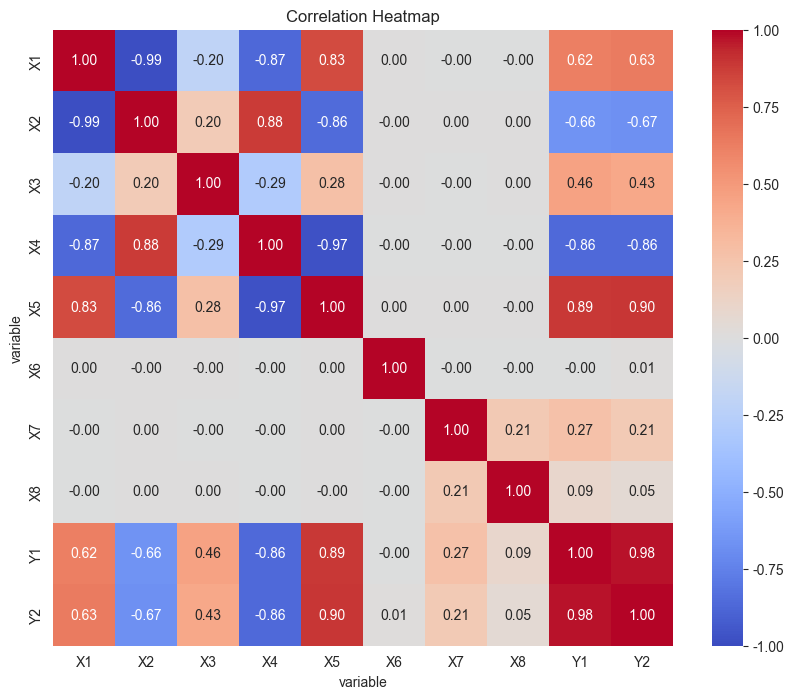

In [15]:
plot_heatmap(corr)

In [16]:
multicollinear_pairs = flag_multicollinearity(corr)
multicollinear_pairs

,feature_1,feature_2,correlation
0,X1,X2,-0.992
1,X1,X4,-0.869
2,X1,X5,0.828
3,X2,X4,0.881
4,X2,X5,-0.858
5,X4,X5,-0.973
6,X4,Y1,-0.862
7,X4,Y2,-0.863
8,X5,Y1,0.889
9,X5,Y2,0.896


In [17]:
correlated_groups = group_correlated_features(corr)
correlated_groups

{'cluster_1': ['X1', 'X2', 'X4', 'X5']}

In [18]:
target_corr = target_correlation(corr)
target_corr

Y1-Y2 correlation: 0.999


variable,Y1,Y2
variable,,
X1,0.910036,0.916979
X2,-0.916847,-0.923774
X3,0.476490,0.468019
X4,-0.979840,-0.984178
X5,0.982373,0.986912
X6,-0.146961,-0.130937
X7,0.159189,0.129201
X8,-0.051315,-0.070817


## 5. 변수 선택 & Separate 회귀모델 (`pipeline_separate.py`)

Y1(Heating Load), Y2(Cooling Load)를 각각 독립적인 LinearRegression 모델로 예측합니다.
변수 선택은 3번(기술통계)과 4번(상관관계) 결과를 함께 참고하여 결정합니다.

In [ ]:
# pipeline_separate.py
# select_features, scale_features, get_dataset, train_and_evaluate, plot_residuals 함수 붙여넣기 


### 5-1. Y1 (Heating Load)

In [ ]:
features_y1 = select_features(df, target="Y1", correlated_groups=correlated_groups, target_corr=target_corr)
features_y1

In [ ]:
X_train_y1, X_test_y1, y_train_y1, y_test_y1 = get_dataset(
    df, features=features_y1, target="Y1", random_state=RANDOM_STATE
)

model_y1, metrics_y1 = train_and_evaluate(X_train_y1, X_test_y1, y_train_y1, y_test_y1)
metrics_y1

In [ ]:
plot_residuals(model_y1, X_test_y1, y_test_y1)

### 5-2. Y2 (Cooling Load)

In [ ]:
features_y2 = select_features(df, target="Y2", correlated_groups=correlated_groups, target_corr=target_corr)
features_y2

In [ ]:
X_train_y2, X_test_y2, y_train_y2, y_test_y2 = get_dataset(
    df, features=features_y2, target="Y2", random_state=RANDOM_STATE
)

model_y2, metrics_y2 = train_and_evaluate(X_train_y2, X_test_y2, y_train_y2, y_test_y2)
metrics_y2

In [ ]:
plot_residuals(model_y2, X_test_y2, y_test_y2)